#### Fig 2c "All niches"

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import scanpy as sc  
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import cell2location 
import pandas as pd
import torch 
import os

pd.set_option('display.max_columns',20)
pd.set_option('display.max_categories',60)
pd.set_option('display.max_rows', 20)
# Set general parameters for publication-ready figures
plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Arial',  # Set font to Arial
    'font.size': 14,  # Set font size to at least 14
    'axes.labelsize': 14,  # Axes labels size
    'axes.titlesize': 16,  # Title size for axes
    'xtick.labelsize': 14,  # X-tick label size
    'ytick.labelsize': 14,  # Y-tick label size
    'legend.fontsize': 14,  # Legend font size
    'figure.titlesize': 16,  # Figure title size
    'lines.linewidth': 2,  # Line width for clarity
    'axes.linewidth': 1.5,  # Axis line width
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'text.color': 'black',  # Make sure text is black (not grey)
    'axes.labelcolor': 'black',  # Ensure axes labels are black
    'axes.edgecolor': 'black',  # Ensure edge of axes is black
    'axes.facecolor': 'white',
    'xtick.color': 'black',  # Ensure X-tick marks are black
    'ytick.color': 'black',  # Ensure Y-tick marks are black
    'axes.titlepad': 20  # Padding for title
})

In [4]:
adata_vis = sc.read_h5ad("/Users/jk/Documents/Lab2/visium/python_analysis/local_401/nmf/ann_finest_level/nfact12/h5ad/adata_vis_assigned_cell_types_nfact12_assigned_factors_log_minmax.h5ad")


In [5]:
adata_vis.obs

,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT0,AT1,AT2,AT2 proliferating,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar Mph MT-positive,Alveolar Mph proliferating,Alveolar fibroblasts,Alveolar macrophages,B cells,Basal resting,CD4 T cells,CD8 T cells,Classical monocytes,Club (nasal),Club (non-nasal),DC1,DC2,Deuterosomal,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Goblet (bronchial),Goblet (nasal),Goblet (subsegmental),Hillock-like,Interstitial Mph perivascular,Ionocyte,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Mesothelium,Migratory DCs,Monocyte-derived Mph,Multiciliated (nasal),Multiciliated (non-nasal),Myofibroblasts,NK cells,Neuroendocrine,Non-classical monocytes,Peribronchial fibroblasts,Pericytes,Plasma cells,Plasmacytoid DCs,SM activated stress response,SMG duct,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Suprabasal,T cells proliferating,Unknown,pre-TB secretory,cell_type_assigned,mean_nUMI_factorsfact_0,mean_nUMI_factorsfact_1,mean_nUMI_factorsfact_2,mean_nUMI_factorsfact_3,mean_nUMI_factorsfact_4,mean_nUMI_factorsfact_5,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,mean_nUMI_factorsfact_9,mean_nUMI_factorsfact_10,mean_nUMI_factorsfact_11,ATI/Endo,Perib. FB,Airway,B,Alv. macro,Alv. FB/immune,Adv. FB,Macro,Immune,SMC,ATII,Plasma,ATI/Endo_log_minmax,Perib. FB_log_minmax,Airway_log_minmax,B_log_minmax,Alv. macro_log_minmax,Alv. FB/immune_log_minmax,Adv. FB_log_minmax,Macro_log_minmax,Immune_log_minmax,SMC_log_minmax,ATII_log_minmax,Plasma_log_minmax,factor_assigned
AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3961,8.284504,7804.0,8.962520,31.765761,35.212711,39.928242,49.410559,629.0,6.445720,8.059970,0.0,0.0,0.0,0.0,0.0,0.0,7804.0,3961,0,0.000967,0.000081,0.000023,0.000279,0.234594,0.009023,0.003434,0.045472,0.387183,0.001108,3.730742,0.001663,0.065855,0.019768,0.004821,0.127872,0.000417,0.008481,0.040385,0.010641,0.001719,0.002331,0.000529,0.001759,0.004936,0.001933,0.000464,0.042375,0.002770,0.058909,0.003027,0.003101,0.008538,0.003847,0.000322,0.044897,0.017594,0.026567,0.000907,0.003966,0.016523,0.092378,0.008129,0.037726,0.014092,0.968134,0.362111,0.025284,0.008943,0.038652,0.060598,0.231837,0.004889,0.044583,0.001354,0.000324,B cells,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469,0.000000,0.000000,0.000000,0.773084,0.000000,0.717544,0.502845,0.000000,0.620036,0.000000,0.000000,0.740151,B
AACACTTGGCAAGGAA-1-18_57617_A1,1.0,47.0,71.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3322,8.108623,5412.0,8.596559,15.909091,20.842572,27.475979,40.742794,280.0,5.638355,5.173688,0.0,0.0,0.0,0.0,0.0,0.0,5412.0,3322,0,0.137828,0.802715,0.341800,0.009572,0.139944,0.039461,0.032829,0.186727,0.888112,0.481472,0.039227,0.013804,0.056936,0.042788,0.031012,0.009081,0.043570,0.023910,0.040213,0.001578,1.365678,0.136504,0.618607,0.156473,0.098999,0.008318,0.010266

In [6]:
niches = np.unique(adata_vis.obs['factor_assigned'])

In [7]:
df = adata_vis[(adata_vis.obs['cond']!="UNC") &     (adata_vis.obs['factor_assigned'].isin(niches))].obs[['library_id','cond', 'factor_assigned']]

In [8]:
df

,library_id,cond,factor_assigned
AACACGTGCATCGCAC-1-18_57617_A1,18_57617_A1,IPF,B
AACACTTGGCAAGGAA-1-18_57617_A1,18_57617_A1,IPF,ATI/Endo
AACAGGATTCATAGTT-1-18_57617_A1,18_57617_A1,IPF,ATI/Endo
AACAGGTTCACCGAAG-1-18_57617_A1,18_57617_A1,IPF,ATI/Endo
AACAGTCAGGCTCCGC-1-18_57617_A1,18_57617_A1,IPF,Macro
...,...,...,...
TGTTCATTGGTCCAAG-1-22_16220_B1,22_16220_B1,IPF,ATI/Endo
TGTTGCGTCCAAGATT-1-22_16220_B1,22_16220_B1,IPF,ATI/Endo
TGTTGGAAGCTCGGTA-1-22_16220_B1,22_16220_B1,IPF,ATI/Endo
TGTTGGATGGACTTCT-1-22_16220_B1,22_16220_B1,IPF,ATII


In [9]:
df['factor_assigned'].isna().sum()

0

In [10]:
print("NaNs in cond:", df['cond'].isna().sum())
print("NaNs in library_id:", df['library_id'].isna().sum())

NaNs in cond: 0
NaNs in library_id: 0


In [16]:
df.groupby(['library_id','cond']).size()

library_id   cond
06_30914_A1  CHP        0
             IPF        0
             NSIP    4507
08_38774_B2  CHP     2575
             IPF        0
             NSIP       0
11_13888_A1  CHP     3617
             IPF        0
             NSIP       0
16_39724_B1  CHP     2630
             IPF        0
             NSIP       0
17_25789_B1  CHP     3674
             IPF        0
             NSIP       0
18_57617_A1  CHP        0
             IPF     3473
             NSIP       0
19_18542_A4  CHP        0
             IPF        0
             NSIP    3889
19_35057_C3  CHP        0
             IPF        0
             NSIP    4311
20_17688_B2  CHP        0
             IPF        0
             NSIP    3489
20_22642_A1  CHP        0
             IPF        0
             NSIP    3539
20_24241_A2  CHP        0
             IPF     4042
             NSIP       0
20_26330_B3  CHP        0
             IPF        0
             NSIP    1475
20_28197_A1  CHP        0
             IPF    

In [11]:
counts = df.groupby(['cond', 'library_id', 'factor_assigned']).size().reset_index(name='count')
print(counts.head())
print(counts.isna().sum())

  cond   library_id factor_assigned  count
0  CHP  06_30914_A1        ATI/Endo      0
1  CHP  06_30914_A1       Perib. FB      0
2  CHP  06_30914_A1            ATII      0
3  CHP  06_30914_A1          Plasma      0
4  CHP  06_30914_A1          Airway      0
cond               0
library_id         0
factor_assigned    0
count              0
dtype: int64


In [12]:
# Step 1: Compute counts and proportions
counts = df.groupby(['cond', 'factor_assigned']).size().reset_index(name='count') # .reset_index() makes a dataframe
#counts = counts[counts['count'] > 0].copy()
total_counts = counts.groupby(['cond'])['count'].transform('sum') # .transform('sum') returns grouped sum the same number of times as the number of rows 
counts['proportion'] = counts['count'] / total_counts

# Step 2: Pivot to get proportions stacked per library_id
pivot_df = counts.pivot_table(
    index='cond',
    columns='factor_assigned',
    values='proportion'
)

In [12]:
pivot_df

factor_assigned,ATI/Endo,Perib. FB,ATII,Plasma,Airway,B,Alv. macro,Alv. FB/immune,Adv. FB,Macro,Immune,SMC
cond,,,,,,,,,,,,
CHP,0.568208,0.010417,0.049001,0.020776,0.026256,0.003539,0.013670,0.160160,0.022317,0.009732,0.071261,0.044663
IPF,0.336252,0.038235,0.056944,0.059419,0.063498,0.002393,0.015392,0.274060,0.050200,0.010959,0.033639,0.059011
NSIP,0.428801,0.038941,0.054922,0.093199,0.040825,0.004187,0.024181,0.144597,0.049932,0.013678,0.046373,0.060365


In [13]:
list(pivot_df.columns)

['ATI/Endo',
 'Perib. FB',
 'ATII',
 'Plasma',
 'Airway',
 'B',
 'Alv. macro',
 'Alv. FB/immune',
 'Adv. FB',
 'Macro',
 'Immune',
 'SMC']

In [14]:
pivot_df[pivot_df.mean().sort_values(ascending=False).index]

factor_assigned,ATI/Endo,Alv. FB/immune,Plasma,SMC,ATII,Immune,Airway,Adv. FB,Perib. FB,Alv. macro,Macro,B
cond,,,,,,,,,,,,
CHP,0.568208,0.160160,0.020776,0.044663,0.049001,0.071261,0.026256,0.022317,0.010417,0.013670,0.009732,0.003539
IPF,0.336252,0.274060,0.059419,0.059011,0.056944,0.033639,0.063498,0.050200,0.038235,0.015392,0.010959,0.002393
NSIP,0.428801,0.144597,0.093199,0.060365,0.054922,0.046373,0.040825,0.049932,0.038941,0.024181,0.013678,0.004187


In [15]:
pivot_df[pivot_df.mean().sort_values(ascending=False).index].columns

CategoricalIndex(['ATI/Endo', 'Alv. FB/immune', 'Plasma', 'SMC', 'ATII',
                  'Immune', 'Airway', 'Adv. FB', 'Perib. FB', 'Alv. macro',
                  'Macro', 'B'],
                 categories=['ATI/Endo', 'Perib. FB', 'ATII', 'Plasma', 'Airway', 'B', 'Alv. macro', 'Alv. FB/immune', 'Adv. FB', 'Macro', 'Immune', 'SMC'], ordered=False, dtype='category', name='factor_assigned')

In [79]:
save_dir = "figs"
os.makedirs(save_dir, exist_ok=True)

In [80]:
paired = ['#a6cee3', '#1f78b4', '#b2df8a', '#33a02c', '#fb9a99', '#e31a1c', '#fdbf6f', '#ff7f00', '#cab2d6', '#6a3d9a', '#ffff99', '#b15928']

In [81]:
import random
random.shuffle(paired)
print(paired)

['#b15928', '#ff7f00', '#6a3d9a', '#1f78b4', '#b2df8a', '#fdbf6f', '#a6cee3', '#ffff99', '#e31a1c', '#cab2d6', '#fb9a99', '#33a02c']


In [82]:
paired_shuffled = ['#ff7f00', '#33a02c', '#fdbf6f', '#1f78b4', '#fb9a99', '#cab2d6', '#6a3d9a', '#ffff99', '#b15928', '#b2df8a', '#a6cee3', '#e31a1c']

In [83]:
pivot_df = pivot_df[pivot_df.mean().sort_values(ascending=False).index].loc[["IPF",'NSIP','CHP'],:]
pivot_df

factor_assigned,ATI/Endo,Alv. FB/immune,Plasma,SMC,ATII,Immune,Airway,Adv. FB,Perib. FB,Alv. macro,Macro,B
cond,,,,,,,,,,,,
IPF,0.336252,0.274060,0.059419,0.059011,0.056944,0.033639,0.063498,0.050200,0.038235,0.015392,0.010959,0.002393
NSIP,0.428801,0.144597,0.093199,0.060365,0.054922,0.046373,0.040825,0.049932,0.038941,0.024181,0.013678,0.004187
CHP,0.568208,0.160160,0.020776,0.044663,0.049001,0.071261,0.026256,0.022317,0.010417,0.013670,0.009732,0.003539


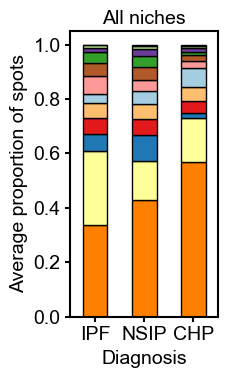

<Figure size 400x200 with 0 Axes>

In [84]:
# Custom color palette
color_dict = dict(zip(
['ATI/Endo',
 'Perib. FB',
 'ATII',
 'Plasma',
 'Airway',
 'B',
 'Alv. macro',
 'Alv. FB/immune',
 'Adv. FB',
 'Macro',
 'Immune',
 'SMC'],
 ['#ff7f00', '#33a02c', '#fdbf6f', '#1f78b4', '#fb9a99', '#cab2d6', '#6a3d9a', '#ffff99', '#b15928', '#b2df8a', '#a6cee3', '#e31a1c']

))

# Sort rows (condition) and columns
pivot_df = pivot_df[pivot_df.mean().sort_values(ascending=False).index].loc[["IPF",'NSIP','CHP'],:]

# Step 2: Plot stacked barplot
ax = pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(2.5, 4),
    #colormap=paired_shuffled,
    color = color_dict,
    edgecolor = "black"
)

# Formatting

ax.set_ylabel("Average proportion of spots")
ax.set_xlabel("Diagnosis")
ax.set_title("All niches", pad = 5, fontsize = 14)
ax.get_legend().remove()
#ax.legend(title="Niches", bbox_to_anchor=(1.02, 1.03), loc='upper left', frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "stacked_bar_log_minmax_all_niches_average.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()



# Extract handles and labels
handles, labels = ax.get_legend_handles_labels()

# Create separate figure for legend
fig_legend = plt.figure(figsize=(4, 2))  # Adjust size as needed
fig_legend.legend(handles, labels, title="Niches", loc='center', frameon=False, ncol=4)  # ncol=2 for horizontal spread
fig_legend.tight_layout()

# Save legend
fig_legend.savefig(os.path.join(save_dir, "legend_log_minmax_niches_only.pdf"), bbox_inches='tight', transparent=True)


In [86]:
# Get the order of niches as they appear in the plot (i.e., pivot_df columns)
niche_order = pivot_df.columns.tolist()

# Get corresponding colors from your color_dict
color_order = [color_dict[niche] for niche in niche_order]

# Optionally, pair them for reference
ordered_colors = dict(zip(niche_order, color_order))

# Print or use as needed
print("Niche Order:", niche_order)
print("Color Order:", color_order)


Niche Order: ['ATI/Endo', 'Alv. FB/immune', 'Plasma', 'SMC', 'ATII', 'Immune', 'Airway', 'Adv. FB', 'Perib. FB', 'Alv. macro', 'Macro', 'B']
Color Order: ['#ff7f00', '#ffff99', '#1f78b4', '#e31a1c', '#fdbf6f', '#a6cee3', '#fb9a99', '#b15928', '#33a02c', '#6a3d9a', '#b2df8a', '#cab2d6']


##### First calculate for each library_id then aggregate by cond
##### When using .mean(), it is mathematically equivalent to just pooling library_id by cond

In [87]:
counts = (
    df
    .groupby(["library_id", "factor_assigned"])
    .size()
)
counts

library_id   factor_assigned
06_30914_A1  ATI/Endo           2876
             Perib. FB             0
             ATII                 26
             Plasma               77
             Airway               13
                                ... 
24_27523_C5  Alv. FB/immune      632
             Adv. FB              74
             Macro               155
             Immune              271
             SMC                  36
Length: 336, dtype: int64

In [88]:
props = counts / counts.groupby(level=0).transform("sum") # for each library_id (level = 0), divide the counts by the sum within that library_id
props

library_id   factor_assigned
06_30914_A1  ATI/Endo           0.638118
             Perib. FB          0.000000
             ATII               0.005769
             Plasma             0.017085
             Airway             0.002884
                                  ...   
24_27523_C5  Alv. FB/immune     0.155016
             Adv. FB            0.018151
             Macro              0.038018
             Immune             0.066470
             SMC                0.008830
Length: 336, dtype: float64

In [89]:
# Add cond back in
props = props.reset_index(name="prop")

props = props.merge(
    df[["library_id", "cond"]].drop_duplicates(),
    on="library_id",
    how="left"
)
props

,library_id,factor_assigned,prop,cond
0,06_30914_A1,ATI/Endo,0.638118,NSIP
1,06_30914_A1,Perib. FB,0.000000,NSIP
2,06_30914_A1,ATII,0.005769,NSIP
3,06_30914_A1,Plasma,0.017085,NSIP
4,06_30914_A1,Airway,0.002884,NSIP
...,...,...,...,...
331,24_27523_C5,Alv. FB/immune,0.155016,CHP
332,24_27523_C5,Adv. FB,0.018151,CHP
333,24_27523_C5,Macro,0.038018,CHP
334,24_27523_C5,Immune,0.066470,CHP


In [99]:
# Aggregate across library_id by cond using mean
mean_props = (
    props
    .groupby(["cond", "factor_assigned"])["prop"]
    .mean()
    .reset_index()
)

In [100]:
pivot_mean_props = mean_props.pivot_table(
    index='cond',
    columns='factor_assigned',
    values='prop'
)
pivot_mean_props

factor_assigned,ATI/Endo,Perib. FB,ATII,Plasma,Airway,B,Alv. macro,Alv. FB/immune,Adv. FB,Macro,Immune,SMC
cond,,,,,,,,,,,,
CHP,0.558888,0.010221,0.051272,0.020131,0.026160,0.003060,0.013716,0.165861,0.024277,0.010082,0.073110,0.043222
IPF,0.334019,0.038893,0.060414,0.058134,0.062759,0.002384,0.015690,0.268092,0.055769,0.011636,0.033746,0.058462
NSIP,0.376056,0.037197,0.088153,0.106132,0.040748,0.004112,0.024468,0.148264,0.059918,0.011768,0.042488,0.060696


In [101]:
pivot_mean_props = pivot_mean_props[pivot_mean_props.mean().sort_values(ascending=False).index].loc[["IPF",'NSIP','CHP'],:]
pivot_mean_props

factor_assigned,ATI/Endo,Alv. FB/immune,ATII,Plasma,SMC,Immune,Adv. FB,Airway,Perib. FB,Alv. macro,Macro,B
cond,,,,,,,,,,,,
IPF,0.334019,0.268092,0.060414,0.058134,0.058462,0.033746,0.055769,0.062759,0.038893,0.015690,0.011636,0.002384
NSIP,0.376056,0.148264,0.088153,0.106132,0.060696,0.042488,0.059918,0.040748,0.037197,0.024468,0.011768,0.004112
CHP,0.558888,0.165861,0.051272,0.020131,0.043222,0.073110,0.024277,0.026160,0.010221,0.013716,0.010082,0.003060


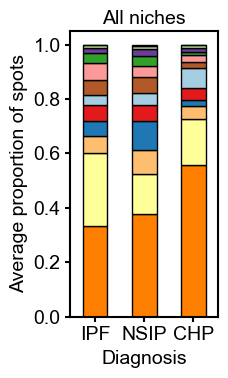

In [102]:
# Custom color palette
color_dict = dict(zip(
['ATI/Endo',
 'Perib. FB',
 'ATII',
 'Plasma',
 'Airway',
 'B',
 'Alv. macro',
 'Alv. FB/immune',
 'Adv. FB',
 'Macro',
 'Immune',
 'SMC'],
 ['#ff7f00', '#33a02c', '#fdbf6f', '#1f78b4', '#fb9a99', '#cab2d6', '#6a3d9a', '#ffff99', '#b15928', '#b2df8a', '#a6cee3', '#e31a1c']

))

# Sort rows (condition) and columns
pivot_mean_props = pivot_mean_props[pivot_mean_props.mean().sort_values(ascending=False).index].loc[["IPF",'NSIP','CHP'],:]

# Step 2: Plot stacked barplot
ax = pivot_mean_props.plot(
    kind='bar',
    stacked=True,
    figsize=(2.5, 4),
    #colormap=paired_shuffled,
    color = color_dict,
    edgecolor = "black"
)

# Formatting

ax.set_ylabel("Average proportion of spots")
ax.set_xlabel("Diagnosis")
ax.set_title("All niches", pad = 5, fontsize = 14)
ax.get_legend().remove()
#ax.legend(title="Niches", bbox_to_anchor=(1.02, 1.03), loc='upper left', frameon=False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "stacked_bar_log_minmax_all_niches_library_id_mean.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()



# # Extract handles and labels
# handles, labels = ax.get_legend_handles_labels()

# # Create separate figure for legend
# fig_legend = plt.figure(figsize=(4, 2))  # Adjust size as needed
# fig_legend.legend(handles, labels, title="Niches", loc='center', frameon=False, ncol=4)  # ncol=2 for horizontal spread
# fig_legend.tight_layout()

# # Save legend
# fig_legend.savefig(os.path.join(save_dir, "legend_log_minmax_niches_only.pdf"), bbox_inches='tight', transparent=True)
